<a href="https://colab.research.google.com/github/rounak393/clab/blob/main/db2dcsamhmam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
os.environ["KAGGLE_API_TOKEN"]='KGAT_c03d989b55c966d18c971a92b023645b'

In [2]:
!kaggle datasets download -d britikak/busi-dataset

Dataset URL: https://www.kaggle.com/datasets/britikak/busi-dataset
License(s): unknown
100% 195M/195M [00:12<00:00, 16.8MB/s]



In [3]:
!unzip -q busi-dataset.zip -d busi_dataset

In [4]:
!pip install albumentations optuna matplotlib torchinfo -q

import os
import copy
import torch
import optuna
import random
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
import albumentations as A
import matplotlib.pyplot as plt
from torchinfo import summary
from tqdm import tqdm

torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_DIR = "/content/busi_dataset/Dataset_BUSI_with_GT"
CLASSES = ["benign", "malignant"]
IMG_SIZE = 256
BATCH_SIZE = 4
MAIN_EPOCHS = 100


OPTUNA_TRIALS = 3
OPTUNA_EPOCHS = 3


train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

class BUSISegmentationDataset(Dataset):
    def __init__(self, base_dir, classes, transform=None):
        self.samples = []
        self.transform = transform
        for cls in classes:
            cls_dir = os.path.join(base_dir, cls)
            if not os.path.exists(cls_dir): continue
            images = [f for f in os.listdir(cls_dir) if f.endswith(".png") and "mask" not in f]
            for img_name in images:
                img_path = os.path.join(cls_dir, img_name)
                base_name = img_name.replace(".png", "")
                mask_files = [f for f in os.listdir(cls_dir) if f.startswith(base_name + "_mask")]
                if not mask_files: continue
                self.samples.append((img_path, [os.path.join(cls_dir, f) for f in mask_files]))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_paths = self.samples[idx]
        image = np.array(Image.open(img_path).convert("RGB"))
        combined_mask = np.zeros(image.shape[:2], dtype=np.uint8)
        for mpath in mask_paths:
            mask = np.array(Image.open(mpath).convert("L"))
            combined_mask = np.logical_or(combined_mask, (mask > 0).astype(np.uint8))
        combined_mask = combined_mask.astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=combined_mask)
            image, combined_mask = augmented["image"], augmented["mask"]

        return torch.from_numpy(image).permute(2, 0, 1).float(), torch.from_numpy(combined_mask).unsqueeze(0).float()

#  Loaders
full_dataset = BUSISegmentationDataset(BASE_DIR, classes=CLASSES, transform=None)
indices = list(range(len(full_dataset)))
np.random.shuffle(indices)

train_sz, val_sz = int(0.8 * len(full_dataset)), int(0.1 * len(full_dataset))
train_ds = Subset(BUSISegmentationDataset(BASE_DIR, CLASSES, train_transform), indices[val_sz:train_sz + val_sz])
val_ds = Subset(BUSISegmentationDataset(BASE_DIR, CLASSES, val_transform), indices[:val_sz])
test_ds = Subset(BUSISegmentationDataset(BASE_DIR, CLASSES, val_transform), indices[train_sz + val_sz:])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 33.9 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [5]:
class Daubechies2DWT(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        h0 = torch.tensor([-0.12940952,  0.22414387,  0.83651630,  0.48296291])
        h1 = torch.tensor([-0.48296291,  0.83651630, -0.22414387, -0.12940952])
        ll = torch.outer(h0, h0)
        lh = torch.outer(h0, h1)
        hl = torch.outer(h1, h0)
        hh = torch.outer(h1, h1)
        filters = torch.stack([ll, lh, hl, hh], dim=0).unsqueeze(1).repeat(in_channels, 1, 1, 1)
        self.register_buffer('filters', filters)
        self.in_channels = in_channels

    def forward(self, x):
        return F.conv2d(x, self.filters, stride=2, padding=1, groups=self.in_channels)

class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.net(x)

class DCSAM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.smooth = nn.AvgPool2d(3, stride=1, padding=1)
        self.ca = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, max(channels // 8, 4), 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(max(channels // 8, 4), channels, 1, bias=False),
            nn.Sigmoid()
        )
        self.sa = nn.Sequential(nn.Conv2d(2, 1, 7, padding=3, bias=False), nn.Sigmoid())

    def forward(self, x):
        x = x + (x - self.smooth(x))
        x = x * self.ca(x)
        sa_in = torch.cat([torch.mean(x, dim=1, keepdim=True), torch.max(x, dim=1, keepdim=True)[0]], dim=1)
        return x * self.sa(sa_in)

class HMAM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        inter = channels // 4
        self.reduce = nn.Conv2d(channels, inter * 3, 1, bias=False)
        self.d1 = nn.Conv2d(inter, inter, 3, padding=1, dilation=1, bias=False)
        self.d3 = nn.Conv2d(inter, inter, 3, padding=3, dilation=3, bias=False)
        self.d5 = nn.Conv2d(inter, inter, 3, padding=5, dilation=5, bias=False)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.pool_conv = nn.Conv2d(channels, inter, 1, bias=False)
        self.fuse = nn.Conv2d(inter * 4, channels, 1, bias=False)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // 8, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // 8, channels, 1, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b1, b2, b3 = torch.split(self.reduce(x), x.shape[1] // 4, dim=1)
        b1, b2, b3 = self.d1(b1), self.d3(b2), self.d5(b3)
        b4 = F.interpolate(self.pool_conv(self.pool(x)), size=x.shape[2:], mode='bilinear', align_corners=False)
        fused = self.fuse(torch.cat([b1, b2, b3, b4], dim=1))
        return fused * self.se(fused)

In [6]:
class HybridUNet(nn.Module):
    def __init__(self, out_channels=1):
        super().__init__()
        # Encoder Path A: ResNet50
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.r_e1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)
        self.r_pool = resnet.maxpool
        self.r_e2 = resnet.layer1
        self.r_e3 = resnet.layer2
        self.r_e4 = resnet.layer3
        self.r_bottleneck = resnet.layer4

        # Encoder Path B: Wavelet Cascade
        self.w_dwt1 = Daubechies2DWT(in_channels=3)
        self.w_conv1 = DoubleConv(3 * 4, 64)
        self.w_dwt2 = Daubechies2DWT(in_channels=64)
        self.w_conv2 = DoubleConv(64 * 4, 256)
        self.w_dwt3 = Daubechies2DWT(in_channels=256)
        self.w_conv3 = DoubleConv(256 * 4, 512)
        self.w_dwt4 = Daubechies2DWT(in_channels=512)
        self.w_conv4 = DoubleConv(512 * 4, 1024)
        self.w_dwt_b = Daubechies2DWT(in_channels=1024)
        self.w_conv_b = DoubleConv(1024 * 4, 2048)

        # Attention Modules
        self.dcsam1 = DCSAM(128)
        self.dcsam2 = DCSAM(512)
        self.dcsam3 = DCSAM(1024)
        self.dcsam4 = DCSAM(2048)
        self.hmam = HMAM(4096)

        # Decoder Path
        self.up4 = nn.ConvTranspose2d(4096, 1024, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(2048 + 1024, 1024)
        self.up3 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(1024 + 512, 512)
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(512 + 256, 256)
        self.up1 = nn.ConvTranspose2d(256, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128 + 64, 64)
        self.up0 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec0 = DoubleConv(32, 32)
        self.final_conv = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        re1 = self.r_e1(x)
        we1 = self.w_conv1(self.w_dwt1(x))
        s1 = self.dcsam1(torch.cat([re1, we1], dim=1))

        re2 = self.r_e2(self.r_pool(re1))
        we2 = self.w_conv2(self.w_dwt2(we1))
        s2 = self.dcsam2(torch.cat([re2, we2], dim=1))

        re3 = self.r_e3(re2)
        we3 = self.w_conv3(self.w_dwt3(we2))
        s3 = self.dcsam3(torch.cat([re3, we3], dim=1))

        re4 = self.r_e4(re3)
        we4 = self.w_conv4(self.w_dwt4(we3))
        s4 = self.dcsam4(torch.cat([re4, we4], dim=1))

        rb = self.r_bottleneck(re4)
        wb = self.w_conv_b(self.w_dwt_b(we4))
        b = self.hmam(torch.cat([rb, wb], dim=1))

        d4 = self.dec4(torch.cat([s4, self.up4(b)], dim=1))
        d3 = self.dec3(torch.cat([s3, self.up3(d4)], dim=1))
        d2 = self.dec2(torch.cat([s2, self.up2(d3)], dim=1))
        d1 = self.dec1(torch.cat([s1, self.up1(d2)], dim=1))

        return self.final_conv(self.dec0(self.up0(d1)))

In [7]:
class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, gamma=1.5, smooth=1e-5):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).view(-1)
        targets = targets.view(-1)
        TP = (probs * targets).sum()
        FP = ((1 - targets) * probs).sum()
        FN = (targets * (1 - probs)).sum()
        tversky = (TP + self.smooth) / (TP + self.alpha * FP + self.beta * FN + self.smooth)
        return (1 - tversky) ** self.gamma

def strict_dice_coef(y_true, logits, smooth=1e-5):
    y_pred = (torch.sigmoid(logits) > 0.5).float().view(-1)
    y_true_f = y_true.view(-1)
    inter = (y_true_f * y_pred).sum()
    return (2. * inter + smooth) / (y_true_f.sum() + y_pred.sum() + smooth)


temp_model = HybridUNet(out_channels=1).to(device)
summary(temp_model, input_size=(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE),
        col_names=["input_size", "output_size", "num_params"],
        depth=4)
del temp_model # Free up VRAM before Optuna starts

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 50.6MB/s]


In [8]:

def objective(trial):
    # Optuna search
    alpha_val = trial.suggest_float('alpha', 0.1, 0.9)
    beta_val = 1.0 - alpha_val # Force balance
    gamma_val = trial.suggest_float('gamma', 1.0, 3.0)

    model_test = HybridUNet(out_channels=1).to(device)
    criterion_test = FocalTverskyLoss(alpha=alpha_val, beta=beta_val, gamma=gamma_val)
    optimizer_test = torch.optim.Adam(model_test.parameters(), lr=2e-4)

    best_v_dice = 0.0
    for epoch in range(OPTUNA_EPOCHS):
        model_test.train()
        for images, masks in train_loader:
            images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
            optimizer_test.zero_grad(set_to_none=True)
            loss = criterion_test(model_test(images), masks)
            loss.backward()
            optimizer_test.step()

        model_test.eval()
        v_dice = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
                v_dice += strict_dice_coef(masks, model_test(images)).item()

        avg_v_dice = v_dice / len(val_loader)
        if avg_v_dice > best_v_dice: best_v_dice = avg_v_dice

    return best_v_dice

# Run the search
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=OPTUNA_TRIALS)

best_alpha = study.best_params['alpha']
best_beta = 1.0 - best_alpha
best_gamma = study.best_params['gamma']

print("\n SCOUTING COMPLETE. OPTIMAL PARAMETERS FOUND:")
print(f"   Alpha: {best_alpha:.4f} | Beta: {best_beta:.4f} | Gamma: {best_gamma:.4f}")

[I 2026-05-21 08:17:53,064] A new study created in memory with name: no-name-211388c3-3f47-45d5-b640-51280c62928f
[I 2026-05-21 08:22:04,700] Trial 0 finished with value: 0.5959663148969412 and parameters: {'alpha': 0.808406596389694, 'gamma': 1.3410416794614906}. Best is trial 0 with value: 0.5959663148969412.
[I 2026-05-21 08:25:52,447] Trial 1 finished with value: 0.6551901400089264 and parameters: {'alpha': 0.6579822124606582, 'gamma': 2.3688538703332567}. Best is trial 1 with value: 0.6551901400089264.
[I 2026-05-21 08:29:39,603] Trial 2 finished with value: 0.5880368500947952 and parameters: {'alpha': 0.2633586128385206, 'gamma': 1.698646303033321}. Best is trial 1 with value: 0.6551901400089264.



 SCOUTING COMPLETE. OPTIMAL PARAMETERS FOUND:
   Alpha: 0.6580 | Beta: 0.3420 | Gamma: 2.3689


Epoch 1/100: 100%|██████████| 130/130 [01:15<00:00,  1.72it/s]


Epoch [1/100] | T-Loss: 0.5480 | T-Dice: 0.3824 | V-Loss: 0.4346 | V-Dice: 0.4977


Epoch 2/100: 100%|██████████| 130/130 [01:14<00:00,  1.74it/s]


Epoch [2/100] | T-Loss: 0.4016 | T-Dice: 0.5356 | V-Loss: 0.3468 | V-Dice: 0.6335


Epoch 3/100: 100%|██████████| 130/130 [01:14<00:00,  1.75it/s]


...

Epoch [98/100] | T-Loss: 0.0132 | T-Dice: 0.8450 | V-Loss: 0.0249 | V-Dice: 0.7976


Epoch 99/100: 100%|██████████| 130/130 [01:14<00:00,  1.75it/s]


Epoch [99/100] | T-Loss: 0.0133 | T-Dice: 0.8472 | V-Loss: 0.0246 | V-Dice: 0.7963


Epoch 100/100: 100%|██████████| 130/130 [01:13<00:00,  1.76it/s]


Epoch [100/100] | T-Loss: 0.0114 | T-Dice: 0.8553 | V-Loss: 0.0265 | V-Dice: 0.7934

  MODEL WEIGHTS LOADED FROM EPOCH: 90 
 FINAL TEST LOSS: 0.0584
 FINAL TEST DICE: 0.7832


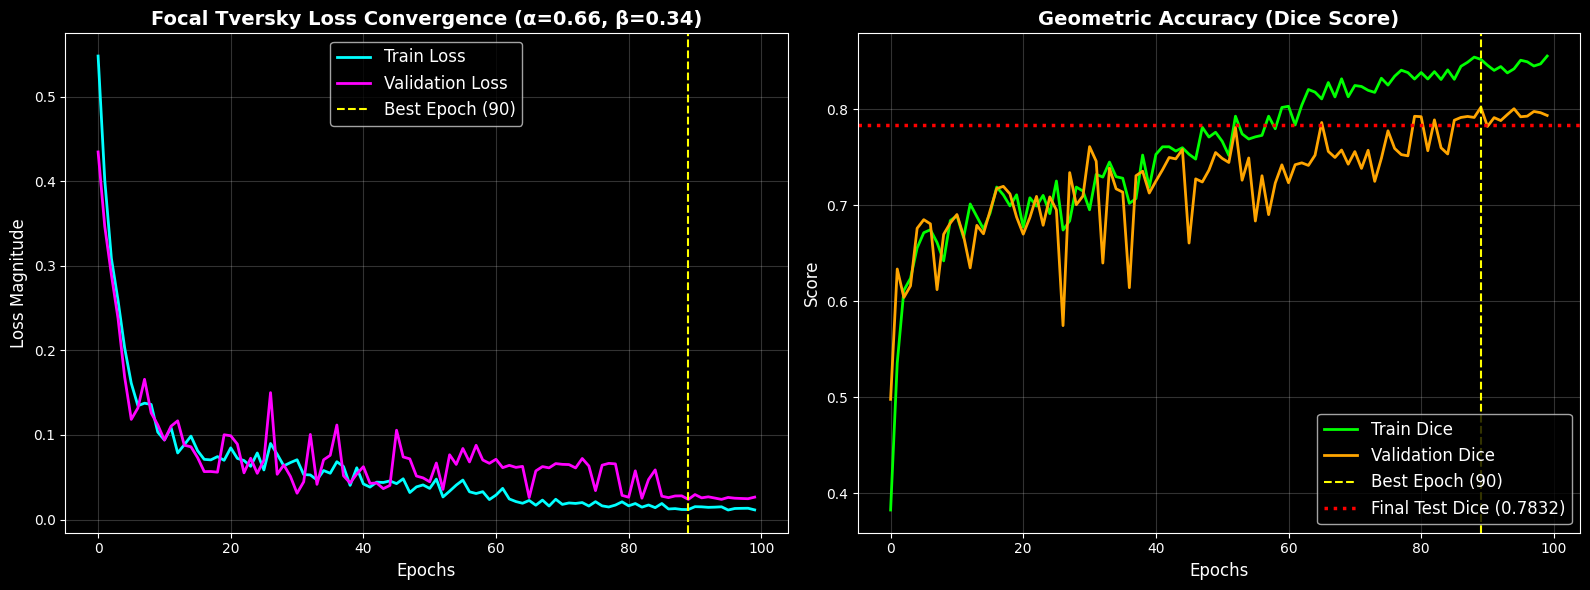

In [9]:


model = HybridUNet(out_channels=1).to(device)
criterion = FocalTverskyLoss(alpha=best_alpha, beta=best_beta, gamma=best_gamma)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAIN_EPOCHS)

train_loss_hist, train_dice_hist = [], []
val_loss_hist, val_dice_hist = [], []
best_val_dice = 0.0
best_model_weights = None
best_epoch = 0

for epoch in range(MAIN_EPOCHS):
    model.train()
    t_loss = t_dice = 0

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{MAIN_EPOCHS}"):
        images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        t_loss += loss.item()
        with torch.no_grad():
            t_dice += strict_dice_coef(masks, logits).item()

    scheduler.step()

    model.eval()
    v_loss = v_dice = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
            logits = model(images)
            loss = criterion(logits, masks)
            v_loss += loss.item()
            v_dice += strict_dice_coef(masks, logits).item()

    avg_t_loss = t_loss / len(train_loader)
    avg_t_dice = t_dice / len(train_loader)
    avg_v_loss = v_loss / len(val_loader)
    avg_v_dice = v_dice / len(val_loader)

    train_loss_hist.append(avg_t_loss); train_dice_hist.append(avg_t_dice)
    val_loss_hist.append(avg_v_loss); val_dice_hist.append(avg_v_dice)

    print(f"Epoch [{epoch+1}/{MAIN_EPOCHS}] | T-Loss: {avg_t_loss:.4f} | T-Dice: {avg_t_dice:.4f} | V-Loss: {avg_v_loss:.4f} | V-Dice: {avg_v_dice:.4f}")

    if avg_v_dice > best_val_dice:
        best_val_dice = avg_v_dice
        best_epoch = epoch + 1
        best_model_weights = copy.deepcopy(model.state_dict())

# --- FINAL EVALUATION ---
print("\n==========================================================")
print(f"  MODEL WEIGHTS LOADED FROM EPOCH: {best_epoch} ")
print("==========================================================")

model.load_state_dict(best_model_weights)
model.eval()

test_loss = test_dice = 0
with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)
        logits = model(images)
        loss = criterion(logits, masks)
        test_loss += loss.item()
        test_dice += strict_dice_coef(masks, logits).item()

avg_test_loss = test_loss / len(test_loader)
avg_test_dice = test_dice / len(test_loader)

print(f" FINAL TEST LOSS: {avg_test_loss:.4f}")
print(f" FINAL TEST DICE: {avg_test_dice:.4f}")

# --- MATPLOTLIB CURVES ---
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(train_loss_hist, label='Train Loss', color='cyan', linewidth=2)
axes[0].plot(val_loss_hist, label='Validation Loss', color='magenta', linewidth=2)
axes[0].axvline(x=best_epoch-1, color='yellow', linestyle='--', label=f'Best Epoch ({best_epoch})')
axes[0].set_title(f'Focal Tversky Loss Convergence (\u03b1={best_alpha:.2f}, \u03b2={best_beta:.2f})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Loss Magnitude', fontsize=12)
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.2)

axes[1].plot(train_dice_hist, label='Train Dice', color='lime', linewidth=2)
axes[1].plot(val_dice_hist, label='Validation Dice', color='orange', linewidth=2)
axes[1].axvline(x=best_epoch-1, color='yellow', linestyle='--', label=f'Best Epoch ({best_epoch})')
axes[1].axhline(y=avg_test_dice, color='red', linestyle=':', linewidth=2.5, label=f'Final Test Dice ({avg_test_dice:.4f})')
axes[1].set_title('Geometric Accuracy (Dice Score)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].legend(fontsize=12, loc='lower right')
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()